**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 12**

# Optimizacion de funciones aplicado a la gestion - Clase 2 📚

# Derivada Parcial 😎

> Antes de avanzar con el siguiente caso primero aprendamos que es una derivada parcial, una herramienta muy util cuando debemos analizar la variacion de una variable respecto a otra.
>> Veamos un ejemplo:


🧠 ¿Qué es una derivada parcial?
Cuando tenés una función con varias variables, como:

$$f(x,y) = 5x^2 + 2y^2$$

La derivada parcial te dice cómo cambia la función cuando solo cambia una variable y las demás se mantienen constantes.

$$\frac{\partial f}{\partial x}=10x$$$$\frac{\partial f}{\partial y}=4y$$




In [ ]:
# 🔧 Librerías necesarias
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize

In [ ]:

# Definir variables simbólicas
x, y = sp.symbols('x y')

# Definir la función
f = 5*x**2 + 2*y**2

# Derivadas parciales
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

# Mostrar resultados
print("Función: f(x, y) =", f)
print("Derivada parcial respecto a x (∂f/∂x):", df_dx)
print("Derivada parcial respecto a y (∂f/∂y):", df_dy)


Función: f(x, y) = 5*x**2 + 2*y**2
Derivada parcial respecto a x (∂f/∂x): 10*x
Derivada parcial respecto a y (∂f/∂y): 4*y


In [15]:
f


-l**2 + l + q**2 + q

In [16]:
df_dx

2*x*y**2

In [17]:
df_dy

2*x**2*y

Hace sentido con lo que veniamos hablando. Veamos otro ejemplo:
$$f(x,y) = x^2 * y^2$$

In [ ]:
# Definir variables simbólicas
x, y = sp.symbols('x y')

# Definir la función
f = x**2 * y**2

# Derivadas parciales
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

# Mostrar resultados
print("Función: f(x, y) =", f)
print("Derivada parcial respecto a x (∂f/∂x):", df_dx)
print("Derivada parcial respecto a y (∂f/∂y):", df_dy)

Función: f(x, y) = x**2*y**2
Derivada parcial respecto a x (∂f/∂x): 2*x*y**2
Derivada parcial respecto a y (∂f/∂y): 2*x**2*y


Sigamos:
$$f(q,l) = q^2 - l^2 + q + l$$

In [ ]:
# Definir variables simbólicas
q, l = sp.symbols('q l')

# Definir la función
f = q**2 - l**2 + q + l

# Derivadas parciales
df_dq = sp.diff(f, q, )
df_dl = sp.diff(f, l)

# Mostrar resultados
print("Función: f(q, l) =", f)
print("Derivada parcial respecto a x (∂f/∂q):", df_dq)
print("Derivada parcial respecto a y (∂f/∂l):", df_dl)

Función: f(q, l) = -l**2 + l + q**2 + q
Derivada parcial respecto a x (∂f/∂q): 2*q + 1
Derivada parcial respecto a y (∂f/∂l): 1 - 2*l


Sigamos:
$$f(x,y) = xy - y^2 + x + 8$$

In [ ]:
# resuelva

Que pasa si agregamos una variable mas?
$$f(x,y,z) = xy - y^2 + x + z$$

In [ ]:
#resuelva
# f(x, y, z) = x*y - y**2 + x + z

x, y, z = sp.symbols('x y z')

# Definir la función
f = x*y - y**2 + x + z

# Derivadas parciales: una por cada variable
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
df_dz = sp.diff(f, z)

print("df/dx =", df_dx)
print("df/dy =", df_dy)
print("df/dz =", df_dz)

# El punto crítico es donde las tres derivadas se anulan a la vez
critico = sp.solve([df_dx, df_dy, df_dz], [x, y, z], dict=True)
print("Puntos críticos:", critico)

# df/dz = 1 nunca se anula: esta función NO tiene punto crítico.
# Interpretación: z siempre suma, así que conviene aumentarla sin límite.

Proponga una ecuacion y escribala con latex en el markdown y a continuacion resuelvala


In [ ]:
# :D



---



---
# 🏛️ Caso 3: repartir un presupuesto público

Hasta acá optimizamos decisiones **de una empresa**. Pero la misma matemática resuelve un problema
que aparece todos los años en cualquier ministerio, municipio o universidad:

> **Hay un presupuesto fijo y varios programas donde ponerlo. ¿Cuánto va a cada uno?**

**La situación.** Un municipio tiene \$ 500 millones para dos programas de un plan de empleo:

| Programa | Qué hace | Personas capacitadas |
|---|---|---|
| **A — Formación en oficios** | Cursos presenciales, talleres | $30\sqrt{x_A}$ |
| **B — Alfabetización digital** | Cursos online, más masivo | $45\sqrt{x_B}$ |

(con $x$ en millones de pesos asignados a cada programa)

**¿Por qué raíz cuadrada?** Porque los dos programas tienen **rendimientos decrecientes**: los
primeros millones capacitan muchísima gente (los que estaban esperando), y a medida que se agranda
hay que ir a buscar gente cada vez más difícil de alcanzar. Es exactamente lo que pasa en la
realidad, y es la razón por la que **volcar todo el presupuesto en un solo programa nunca es óptimo**.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

PRESUPUESTO = 500     # millones de pesos

xA, xB = sp.symbols("x_A x_B", positive=True)

# Cuánta gente capacita cada programa
personas_A = 30 * sp.sqrt(xA)
personas_B = 45 * sp.sqrt(xB)

# La restricción: todo lo que no va a A, va a B
total = personas_A.subs(xA, xA) + personas_B.subs(xB, PRESUPUESTO - xA)

print("Personas capacitadas en total:", total)

# Optimizamos en una sola variable (la restricción ya está adentro)
derivada = sp.diff(total, xA)
xA_opt = sp.solve(sp.Eq(derivada, 0), xA)[0]
xB_opt = PRESUPUESTO - xA_opt

print(f"\nAsignación óptima:")
print(f"   Programa A (oficios) : $ {float(xA_opt):6.1f} millones")
print(f"   Programa B (digital) : $ {float(xB_opt):6.1f} millones")
print(f"   Personas capacitadas : {float(total.subs(xA, xA_opt)):,.0f}")

In [ ]:
# ¿Qué pasa si el intendente decide poner todo en un solo programa?
def capacitados(asignado_a_A):
    return 30 * np.sqrt(asignado_a_A) + 45 * np.sqrt(PRESUPUESTO - asignado_a_A)

escenarios = {
    "Todo al programa A":        499.9,
    "Mitad y mitad":             250.0,
    "Óptimo calculado":          float(xA_opt),
    "Todo al programa B":          0.1,
}

for nombre, valor in escenarios.items():
    print(f"{nombre:<22} → {capacitados(valor):8,.0f} personas")

In [ ]:
# El gráfico completo: cuánta gente se capacita según cómo se reparta
x_vals = np.linspace(1, PRESUPUESTO - 1, 400)
y_vals = capacitados(x_vals)

plt.figure(figsize=(9, 5))
plt.plot(x_vals, y_vals, linewidth=3)
plt.axvline(float(xA_opt), color='black', linestyle=':',
            label=f"Óptimo: $ {float(xA_opt):.0f} M al programa A")
plt.scatter([float(xA_opt)], [capacitados(float(xA_opt))], color='red', s=80, zorder=5)
plt.xlabel("Millones asignados al Programa A (el resto va al B)")
plt.ylabel("Personas capacitadas en total")
plt.title("Cómo repartir el presupuesto entre dos programas")
plt.legend()
plt.grid(alpha=.3)
plt.show()

### 🧠 La regla que se esconde acá

Mirá el resultado: **al programa B le toca más plata, pero no toda**. Y eso pasa aunque B sea más
eficiente en todos los tramos.

La condición del óptimo tiene una lectura clarísima, y es la misma en un ministerio que en una empresa:

> **En el punto óptimo, el último peso puesto en cada programa rinde lo mismo.**

Si el último peso en A capacitara más gente que el último peso en B, convendría mover plata de B
hacia A. Se mueve hasta que se emparejan: ahí ya no hay nada que ganar reasignando.

**Por eso los extremos son malos.** Poner todo en el programa "más eficiente" ignora que su
rendimiento **cae** a medida que crece. Es el error más común en la discusión pública de un
presupuesto: se compara el promedio de cada programa, cuando lo que hay que comparar es **el margen**.

| Lo que se suele preguntar | Lo que habría que preguntar |
|---|---|
| ¿Qué programa es más eficiente? | ¿Cuánto rinde **el próximo peso** en cada programa? |
| ¿Cuánto le dimos el año pasado? | ¿Sigue rindiendo igual con más presupuesto? |

> 💼 **Y es exactamente el mismo problema** que repartir un presupuesto de marketing entre canales,
> horas de un equipo entre proyectos, o inversión entre sucursales. Cambia el nombre, no la matemática.

In [ ]:
# Para practicar: verificá la regla del "último peso"
# Calculá la derivada de cada programa por separado, evaluada en el óptimo.
# Si la regla es cierta, los dos números tienen que dar IGUAL.

# Tu código acá

# Caso de B: Optimización de Trabajo y Capital en la Industria Automotriz 🚗

Imaginemos a "AutoFuturo S.A.", una nueva empresa automotriz que busca establecer una línea de producción para un modelo de vehículo eléctrico innovador. Para ser competitivos, necesitan minimizar los costos de fabricación para alcanzar una meta de producción de 100 vehículos por día.

La producción de cada vehículo requiere una combinación de dos factores clave:

*   **Trabajo (L):** La mano de obra especializada (ingenieros, técnicos, operarios) que ensambla y supervisa el proceso. El costo de una unidad de trabajo (por ejemplo, horas de mano de obra calificada) es de \$10.
*   **Capital (K):** La maquinaria, robots, herramientas y tecnología utilizada en la línea de ensamblaje. El costo de una unidad de capital (por ejemplo, horas de uso de maquinaria avanzada) es de \$5.

La tecnología de producción de AutoFuturo S.A. se describe mediante la siguiente función de producción:

$$Q(L, K) = \sqrt{L \cdot K}$$

Donde:
*   $Q$ es la cantidad de vehículos producidos por día.
*   $L$ es la cantidad de unidades de trabajo utilizadas.
*   $K$ es la cantidad de unidades de capital utilizadas.

Esta función de producción, una forma de Cobb-Douglas, implica que tanto el trabajo como el capital son necesarios para la producción y que hay rendimientos a escala constantes (si duplicas tanto L como K, duplicas la producción).

AutoFuturo S.A. tiene como objetivo producir exactamente 100 vehículos por día. Por lo tanto, la restricción de producción es:

$$\sqrt{L \cdot K} = 100$$

O, elevando ambos lados al cuadrado:
$$L \cdot K = 10000$$

El costo total de producción ($C$) depende de las cantidades de trabajo ($L$) y capital ($K$) utilizadas y de sus respectivos precios ($w=10$ para el trabajo y $r=5$ para el capital):

$$C(L, K) = wL + rK = 10L + 5K$$


**El Desafío de AutoFuturo S.A.:** 🚗

El desafío para AutoFuturo S.A. es encontrar la combinación óptima de trabajo ($L^*$) y capital ($K^*$) que les permita producir los 100 vehículos diarios al menor costo total posible.

Este problema se resuelve utilizando técnicas de optimización restringida. Gráficamente, esto implica encontrar el punto donde una curva de isocosto (que representa todas las combinaciones de L y K que cuestan lo mismo) es tangente a la isocuanta (que representa todas las combinaciones de L y K que producen 100 unidades).

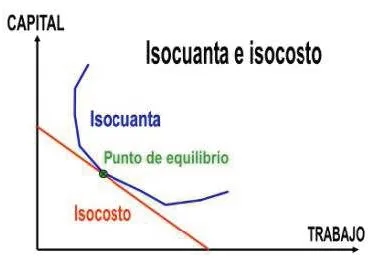

El objetivo es encontrar $L^*$ y $K^*$ tales que $10L^* + 5K^*$ sea mínimo, cumpliendo siempre la condición $\sqrt{L^* \cdot K^*} = 100$. La solución a este problema indicará a AutoFuturo S.A. cuántas unidades de trabajo y capital deben emplear para fabricar sus 100 vehículos eléctricos de la manera más eficiente en costos.

In [ ]:
# Función de costo
def costo(x):
    L, K = x
    return 10*L + 5*K  # Costo total

# Restricción: producir 100 unidades
def restriccion(x):
    L, K = x
    return (L * K)**0.5 - 100

# Llamamos al optimizador
res = minimize(costo, x0=[10, 10], constraints={'type': 'eq', 'fun': restriccion})

# Mostramos los resultados
L_opt, K_opt = res.x
print(f"L* = {L_opt:.2f}")
print(f"K* = {K_opt:.2f}")
print(f"Costo mínimo = {costo([L_opt, K_opt]):.2f}")
C_opt = costo([L_opt, K_opt])

L* = 70.71
K* = 141.42
Costo mínimo = 1414.21


Perfect --> Sabemos las cantidades optimas de trabajo y capital que precisa la automotriz para producir 100 unidades de automoviles, arrojando un costo minimo de \$1414,21

## Gráfico del caso 🙂


1.  **Calcular la Isocuanta:** Se utilizó la restricción de producción $L \cdot K = 10000$ (derivada de $\sqrt{L \cdot K} = 100$) para despejar $K$ en función de $L$. La ecuación de la isocuanta es $K = \frac{10000}{L}$.

2.  **Calcular la Isocosto Óptima:** Se utilizó el costo mínimo (`C_opt`) encontrado previamente por el optimizador. La ecuación general de una línea de isocosto es $C = wL + rK$. Despejando $K$: $K = \frac{C - wL}{r}$. Con $w=10$, $r=5$ y el costo mínimo `C_opt`, la ecuación de la isocosto óptima es $K = \frac{C_{opt} - 10L}{5}$. Se definió una función `isocosto(L, C)` para calcular estos valores de K para diferentes valores de L a un costo fijo C. Luego se graficó `L_vals` contra `isocosto(L_vals, C_opt)` para dibujar la línea de isocosto que pasa por el punto óptimo.

3.  **Marcar el Punto Óptimo:** Los valores óptimos de Trabajo (`L_opt`) y Capital (`K_opt`) obtenidos del resultado de la optimización (`res.x`) se graficaron como un punto rojo ('ro') para mostrar visualmente la combinación de L y K que minimiza el costo.


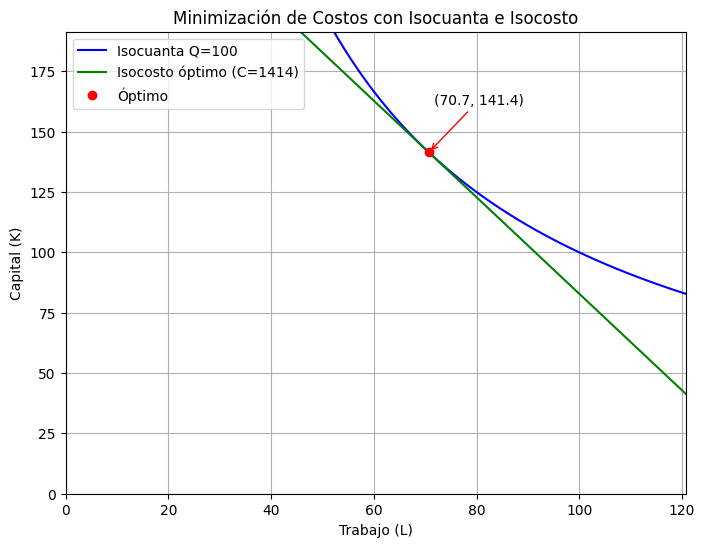

In [ ]:
# Rango para graficar
L_vals = np.linspace(1, L_opt + 50, 100)
K_vals_isoq = (100**2) / L_vals  # K = (Q^2) / L

# Función de isocosto
def isocosto(L, C): return (C - 10*L) / 5

# Gráfico
plt.figure(figsize=(8,6))
plt.plot(L_vals, K_vals_isoq, label='Isocuanta Q=100', color='blue')
plt.plot(L_vals, isocosto(L_vals, C_opt), label=f'Isocosto óptimo (C={C_opt:.0f})', color='green')

# Punto óptimo
plt.plot(L_opt, K_opt, 'ro', label='Óptimo')
plt.annotate(f'({L_opt:.1f}, {K_opt:.1f})',
             xy=(L_opt, K_opt), xytext=(L_opt+1, K_opt+20),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

# Ajuste de ejes
plt.xlim(0, L_opt + 50)
plt.ylim(0, K_opt + 50)

plt.xlabel("Trabajo (L)")
plt.ylabel("Capital (K)")
plt.title("Minimización de Costos con Isocuanta e Isocosto")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#@title Easter egg 🥚
from IPython.display import Image
Image(url='https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExc3lzMzFhcXJhOTJ3MDNpZDhmYXUyMzZ2eWdpZnQ0d2FtYm43ODhhZyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/mGK1g88HZRa2FlKGbz/giphy.gif')

---
#Ejercicios

De los siguientes ejercicios escoja uno y resuelvalo con sus compañeros, el ejercicio restante queda como opcional y suma nota. tenga encuenta que la dificultad de estos ejercicios es alta.

## Ejercicio 5: Minimización de Costos con Dos Variables y Restricción

Una empresa produce utilizando trabajo ($L$) y capital ($K$) con la siguiente función de producción:

$$Q(L, K) = L^{0.4} K^{0.4}$$

El costo del trabajo es $w = 15$ y el costo del capital es $r = 10$. La empresa quiere producir exactamente 200 unidades.

$$C(L, K) = 15L + 10K$$

**Objetivo:**

1.  Plantear el problema de minimizar $C(L, K)$ sujeto a la restricción $L^{0.4} K^{0.6} = 200$.
2.  Utilizar una herramienta de optimización (como `scipy.optimize.minimize`) para encontrar las cantidades óptimas de trabajo ($L^*$) y capital ($K^*$) que minimizan el costo.
3.  Calcular el costo mínimo.

---
## 📋 Cómo se corrige (la rúbrica)

Vale la pena tenerla presente **mientras resolvés**, no cuando ya entregaste. El examen tiene
**dos partes obligatorias** y hay que sacar **4 puntos en cada una** por separado: aprobar una y
desaprobar la otra **no alcanza**.

### Parte 1 — Escrita, en papel (5 puntos)

| Criterio | Peso | Qué se mira |
|---|---|---|
| **Interpretación** | 85% | La lectura **económica** del resultado y conclusiones pertinentes |
| **Interpretación matemática** | 15% | Que entiendas el proceso matemático que hay detrás |

### Parte 2 — Práctica, en computadora (5 puntos)

| Criterio | Peso | Qué se mira |
|---|---|---|
| **Claridad de código** | 85% | Que **ejecute de punta a punta**, orden, comentarios mínimos, funciones limpias, reproducibilidad |
| **Corrección técnica** | 10% | Resultados, signos, unidades, consistencia |
| **Presentación** | 5% | Código prolijo, gráficos legibles, **ejes y leyendas etiquetados**, nombres de variables claros |

### 🎯 Lo que esto significa en la práctica

Mirá los pesos: **el 85% de la parte escrita es interpretación**, y el 85% de la práctica es que el
código sea claro y corra. Traducido:

| ❌ No alcanza con | ✅ Lo que se evalúa |
|---|---|
| Llegar al número correcto | Explicar **qué significa** ese número para la organización |
| Que el código "funcione en mi máquina" | Que corra **de punta a punta**, de arriba a abajo, sin errores |
| Un gráfico que se ve | Un gráfico **con título, ejes etiquetados y leyenda** |

> 🚨 **El error más caro y más evitable:** entregar un notebook que no corre entero. Antes de
> entregar, hacé **Entorno de ejecución → Reiniciar y ejecutar todo**. Si falla ahí, falla en la
> corrección: es el 85% de la parte práctica.

> 📎 Las pautas completas (fechas, modalidad de entrega, nombre del archivo, materiales permitidos)
> están en `CuestionesAdministrativas/Pautas/Pautas_examen.pdf`. **Leelas antes del parcial.**

# Bibliografia y Recomendaciones 📚



*   Libros =

    1.  Big data de walter sosa escudero.
    2.  Viajar al futuro de walter sosa escudero.
